# CNN-Based DNA Promoter Classification

IF3211 Domain-Specific Computation

# 1. Data Preparation & Preprocessing

## 1.1 Data Preparation

In [1]:
# Import Library
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)

In [2]:
# Load Dataset
df = pd.read_csv("/content/promoters.data", header=None)

df.head()

,0,1,2
0,+,S10,\t\ttactagcaatacgcttgcgttcggtggttaagtatgtataat...
1,+,AMPC,\t\ttgctatcctgacagttgtcacgctgattggtgtcgttacaat...
2,+,AROH,\t\tgtactagagaactagtgcattagcttatttttttgttatcat...
3,+,DEOP2,\taattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaa...
4,+,LEU1_TRNA,\ttcgataattaactattgacgaaaagctgaaaaccactagaatgc...


In [3]:
# Rename Columns
df.columns = [
    'class',
    'id',
    'sequence'
]

df.head()

,class,id,sequence
0,+,S10,\t\ttactagcaatacgcttgcgttcggtggttaagtatgtataat...
1,+,AMPC,\t\ttgctatcctgacagttgtcacgctgattggtgtcgttacaat...
2,+,AROH,\t\tgtactagagaactagtgcattagcttatttttttgttatcat...
3,+,DEOP2,\taattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaa...
4,+,LEU1_TRNA,\ttcgataattaactattgacgaaaagctgaaaaccactagaatgc...


In [4]:
# Clean DNA Sequence
df['sequence'] = (
    df['sequence']
    .str.replace('\t', '', regex=False)
    .str.replace(' ', '', regex=False)
    .str.upper()
)

df.head()

,class,id,sequence
0,+,S10,TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGC...
1,+,AMPC,TGCTATCCTGACAGTTGTCACGCTGATTGGTGTCGTTACAATCTAA...
2,+,AROH,GTACTAGAGAACTAGTGCATTAGCTTATTTTTTTGTTATCATGCTA...
3,+,DEOP2,AATTGTGATGTGTATCGAAGTGTGTTGCGGAGTAGATGTTAGAATA...
4,+,LEU1_TRNA,TCGATAATTAACTATTGACGAAAAGCTGAAAACCACTAGAATGCGC...


In [5]:
# Check Unique Characters
unique_chars = set(''.join(df['sequence']))

print(unique_chars)

{'C', 'T', 'G', 'A'}


In [6]:
# Dataset Overview
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['class'].value_counts())

Dataset Shape: (106, 3)

Missing Values:
class       0
id          0
sequence    0
dtype: int64

Class Distribution:
class
+    53
-    53
Name: count, dtype: int64


## 1.2 DNA Sequence Encoding

In [7]:
# Label Encoding
df['label'] = df['class'].map({
    '+': 1,
    '-': 0
})

In [8]:
# One-Hot Encoding Function
def one_hot_encode(sequence):

    mapping = {
        'A': [1,0,0,0],
        'T': [0,1,0,0],
        'G': [0,0,1,0],
        'C': [0,0,0,1]
    }

    return np.array([
        mapping[nucleotide]
        for nucleotide in sequence
    ])

In [9]:
# Encode DNA Sequence
X = np.array([
    one_hot_encode(seq)
    for seq in df['sequence']
])

y = df['label'].values

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (106, 57, 4)
Shape y: (106,)


## 1.3 Train-Test Split

In [10]:
# Split Dataset
from sklearn.model_selection import train_test_split

sequences = df['sequence']

X_temp, X_test, y_temp, y_test, seq_temp, seq_test = train_test_split(
    X,
    y,
    sequences,
    test_size=10,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val, seq_train, seq_val = train_test_split(
    X_temp,
    y_temp,
    seq_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

train_df = pd.DataFrame({
    'sequence': seq_train,
    'label': y_train
})

val_df = pd.DataFrame({
    'sequence': seq_val,
    'label': y_val
})

test_df = pd.DataFrame({
    'sequence': seq_test,
    'label': y_test
})

# Export CSV Files
train_df.to_csv("train.csv", index=False)
val_df.to_csv("validation.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print()

print("y_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

X_train shape: (76, 57, 4)
X_val shape  : (20, 57, 4)
X_test shape : (10, 57, 4)

y_train shape: (76,)
y_val shape  : (20,)
y_test shape : (10,)


# 2. CNN Model Development

## 2.1 Model Compilation

In [11]:
# Build CNN Model
cnn_model = Sequential([

    Input(shape=(57, 4)),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu'
    ),

    MaxPooling1D(pool_size=2),

    Dropout(0.3),

    Flatten(),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

In [12]:
# Model Summary
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 55, 64)         │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1728)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        55,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,193 (219.50 KB)

 Trainable params: 56,193 (219.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compile CNN Model
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 2.2 Model Training

In [14]:
# Train CNN Model
history = cnn_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=8,
    validation_data=(X_val, y_val)
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.5000 - loss: 0.6859 - val_accuracy: 0.9000 - val_loss: 0.6059
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8026 - loss: 0.5497 - val_accuracy: 0.8000 - val_loss: 0.5467
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9868 - loss: 0.4193 - val_accuracy: 0.9500 - val_loss: 0.4744
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9737 - loss: 0.3364 - val_accuracy: 0.9500 - val_loss: 0.4114
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9737 - loss: 0.2781 - val_accuracy: 0.9500 - val_loss: 0.3632
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9868 - loss: 0.2221 - val_accuracy: 0.9500 - val_loss: 0.3273
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.1602 - val_accuracy: 0.9500 - val_loss: 0.3000
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9868 - loss: 0.1278 - val_accuracy: 0.9500 - v

# 3. Model Evaluation

In [15]:
# Predict Test Data
y_pred_prob = cnn_model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


In [16]:
# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("CNN Accuracy :", accuracy)
print("CNN Precision:", precision)
print("CNN Recall   :", recall)
print("CNN F1-Score :", f1)

CNN Accuracy : 0.9
CNN Precision: 0.8333333333333334
CNN Recall   : 1.0
CNN F1-Score : 0.9090909090909091


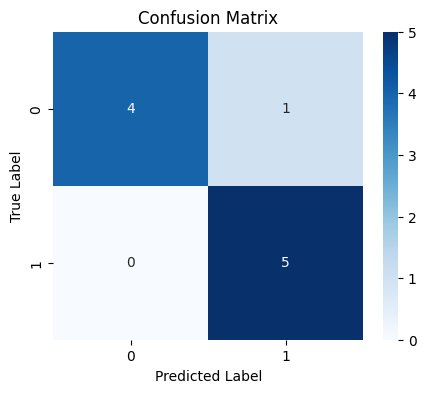

In [17]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [18]:
# Save Model
cnn_model.save("promoter_cnn_model.h5")